In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

In [82]:
df=pd.read_excel("premiums_rest.xlsx")
df.head(3)

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164


In [83]:
df.shape

(29904, 13)

In [84]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [85]:
df.columns = df.columns.str.replace(" ", "_").str.lower()
df.head(3)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164


In [86]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           9
employment_status        1
income_level             9
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

### Handle NA value 

In [87]:
df.dropna(inplace=True)
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

### Duplicate handling

In [88]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [89]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,29886.000000,29886.000000,29886.000000,29886.000000
mean,43.396105,2.379910,23.364184,20892.303821
std,13.412657,1.431201,24.740339,6936.813440
min,26.000000,-3.000000,1.000000,3625.000000
25%,34.000000,1.000000,7.000000,15697.250000
50%,42.000000,3.000000,17.000000,20489.000000
75%,52.000000,3.000000,32.000000,26360.000000
max,356.000000,5.000000,930.000000,43471.000000


In [90]:
df[df['number_of_dependants'] < 0].shape

(50, 13)

In [91]:
df[df.number_of_dependants < 0]['number_of_dependants'].unique()

array([-1, -3])

In [92]:
df['number_of_dependants'] = abs(df['number_of_dependants'])

In [93]:
df[df['number_of_dependants'] < 0].shape

(0, 13)

In [94]:
df['number_of_dependants'].describe()

count    29886.000000
mean         2.385933
std          1.421137
min          0.000000
25%          1.000000
50%          3.000000
75%          3.000000
max          5.000000
Name: number_of_dependants, dtype: float64

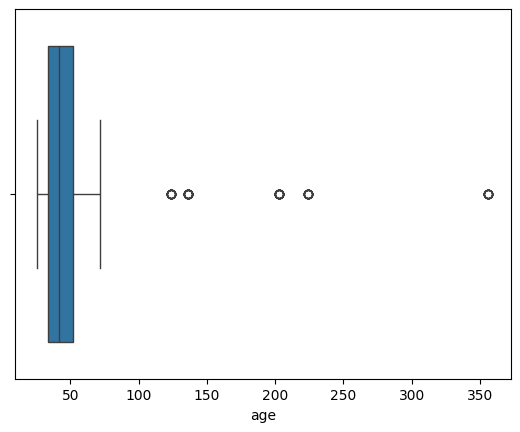

In [95]:
sns.boxplot(x=df['age'])
plt.show()

In [96]:
numeric_columns = df.select_dtypes(include=np.number).columns

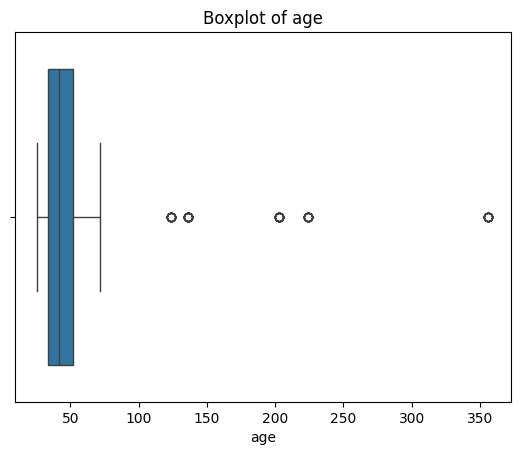

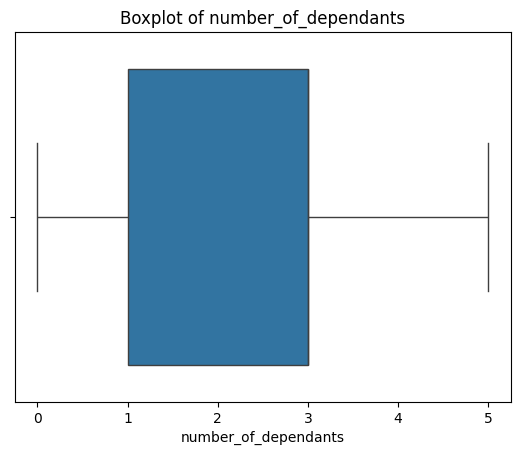

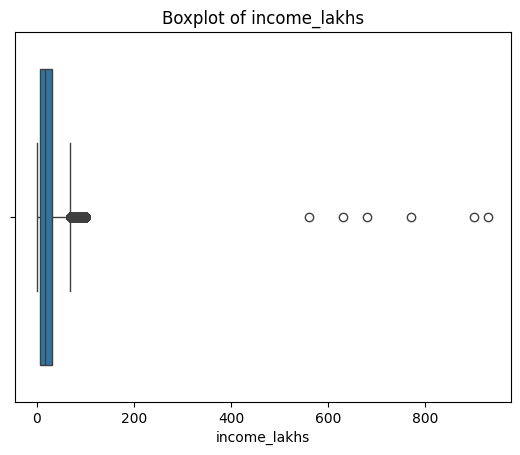

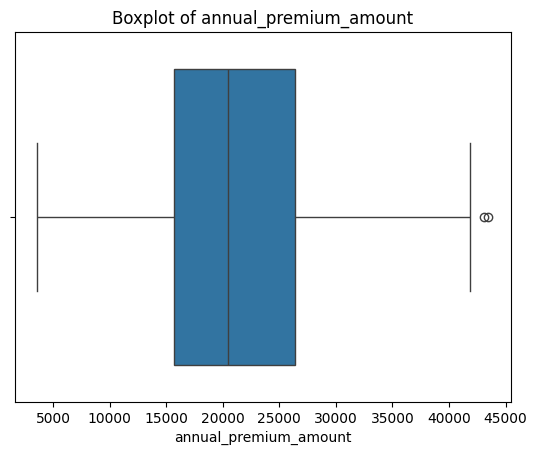

In [97]:
for col in numeric_columns:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [98]:
df[df.age>100]['age'].unique()

array([224, 124, 136, 203, 356])

In [99]:
df1 = df[df.age<=100].copy()
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,29828.000000,29828.000000,29828.000000,29828.000000
mean,43.095380,2.387790,23.371530,20901.900563
std,11.041991,1.420641,24.751262,6928.457636
min,26.000000,0.000000,1.000000,6538.000000
25%,34.000000,1.000000,7.000000,15706.000000
50%,42.000000,3.000000,17.000000,20496.000000
75%,52.000000,3.000000,32.000000,26361.000000
max,72.000000,5.000000,930.000000,43471.000000


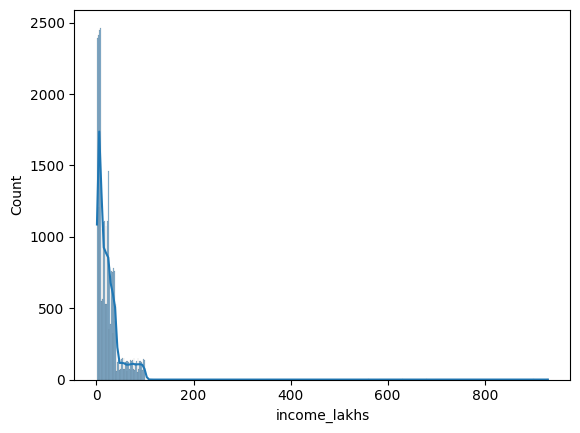

In [100]:
sns.histplot(df1.income_lakhs, kde=True)
plt.show()

In [101]:
df1.income_lakhs.quantile([0.25, 0.75])


0.25     7.0
0.75    32.0
Name: income_lakhs, dtype: float64

In [102]:
def get_iqr_bounds(col):
    Q1, Q3 = col.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

In [103]:
get_iqr_bounds(df1.income_lakhs)

(-30.5, 69.5)

In [104]:
quantile_threshold = df1.income_lakhs.quantile(0.999)
quantile_threshold

np.float64(100.0)

In [105]:
df1[df1.income_lakhs > quantile_threshold].shape

(6, 13)

In [106]:
df2 = df1[df1.income_lakhs <= quantile_threshold].copy()
df2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,29822.000000,29822.000000,29822.000000,29822.000000
mean,43.094896,2.387734,23.226343,20900.689223
std,11.042430,1.420644,22.455408,6928.192115
min,26.000000,0.000000,1.000000,6538.000000
25%,34.000000,1.000000,7.000000,15705.250000
50%,42.000000,3.000000,17.000000,20495.500000
75%,52.000000,3.000000,32.000000,26360.000000
max,72.000000,5.000000,100.000000,43471.000000


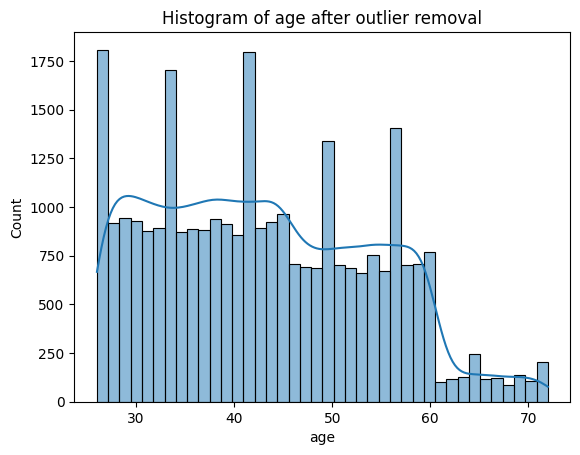

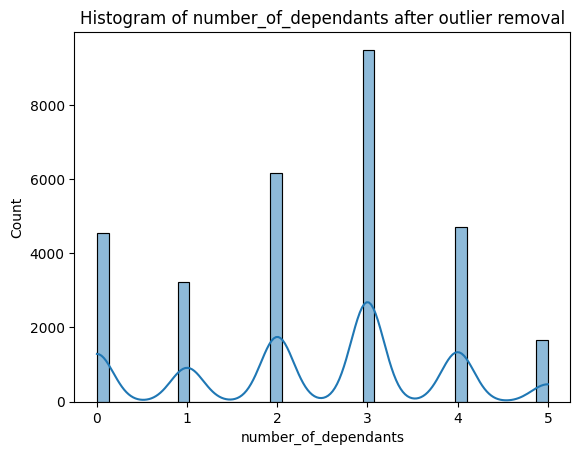

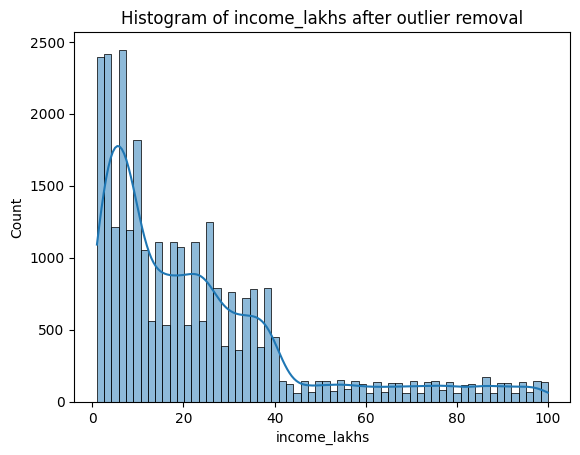

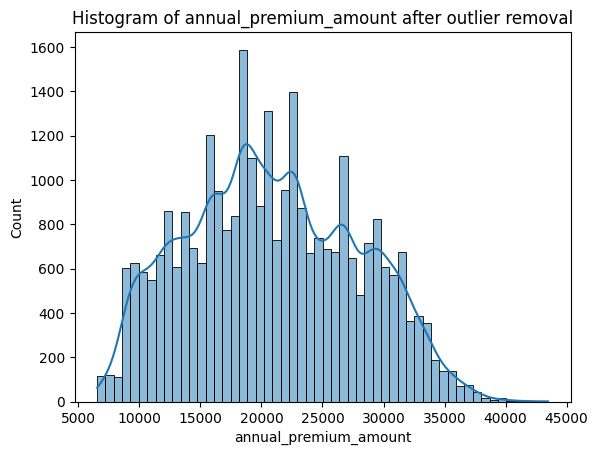

In [107]:

for col in numeric_columns:
    sns.histplot(df2[col], kde=True)
    plt.title(f'Histogram of {col} after outlier removal')
    plt.show()

plt.show()

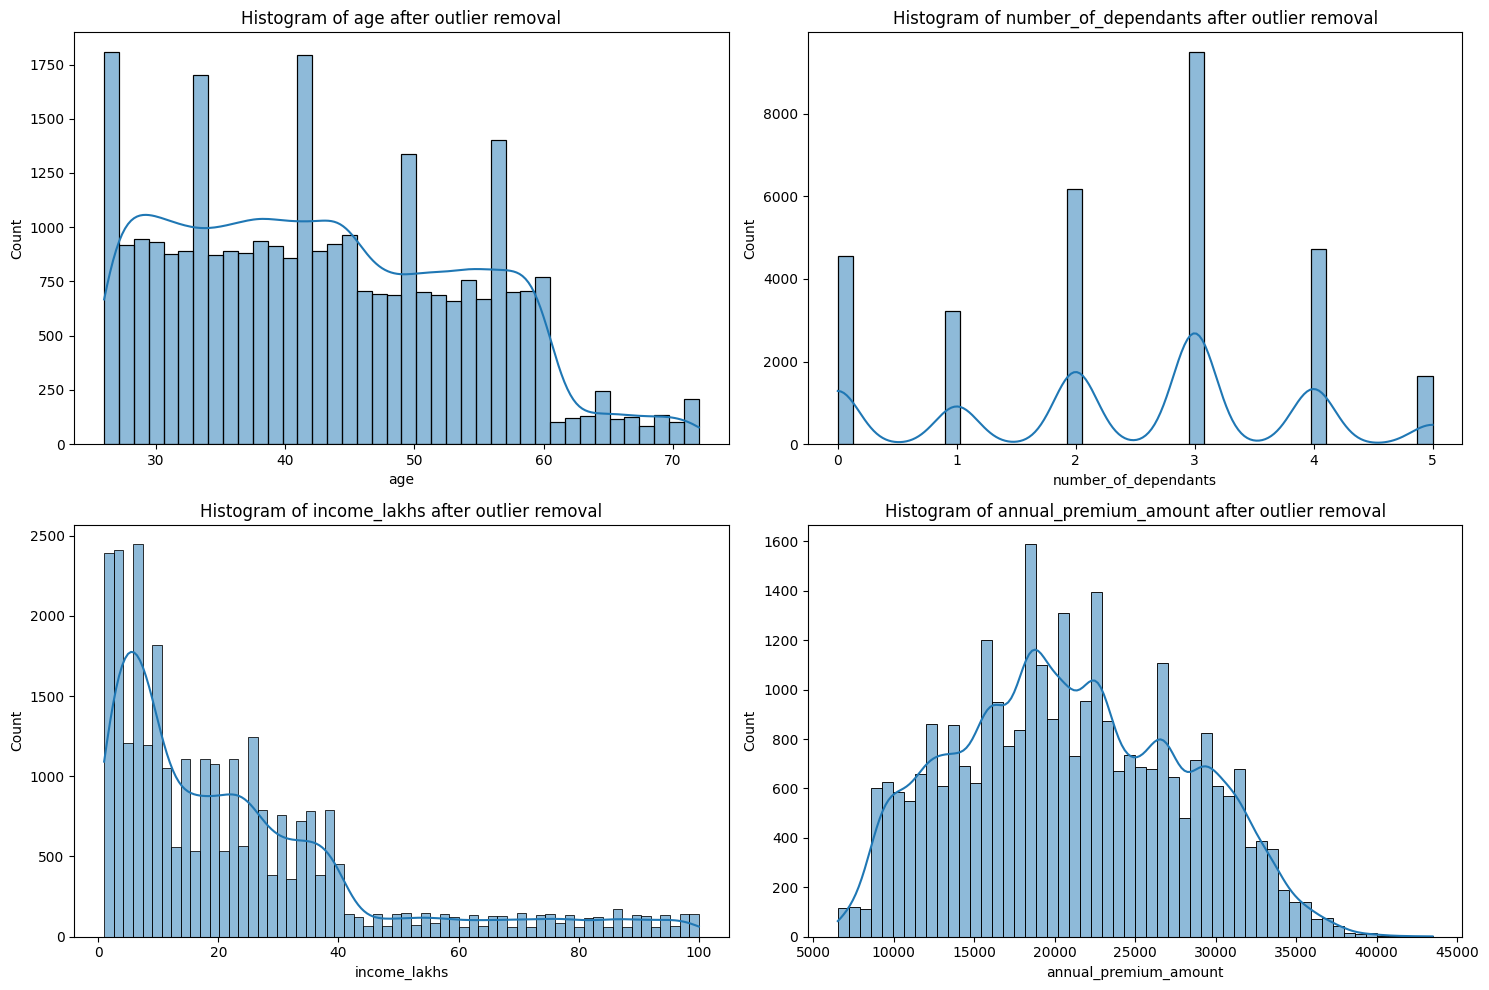

In [108]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for i, col in enumerate(numeric_columns):
    sns.histplot(df2[col], kde=True, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Histogram of {col} after outlier removal')
plt.tight_layout()
plt.show()

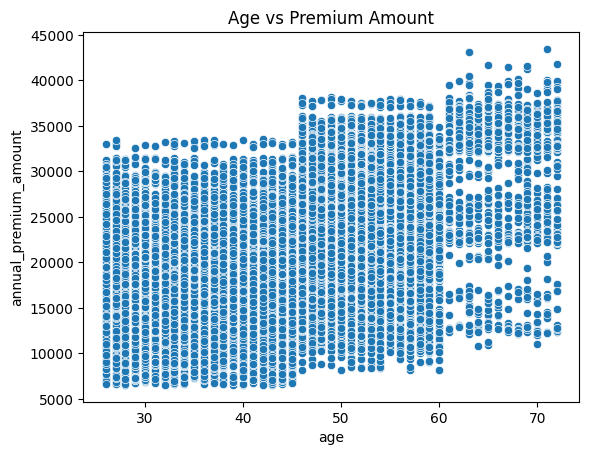

In [109]:
sns.scatterplot(x=df2['age'], y=df2['annual_premium_amount'])
plt.title('Age vs Premium Amount')
plt.show()

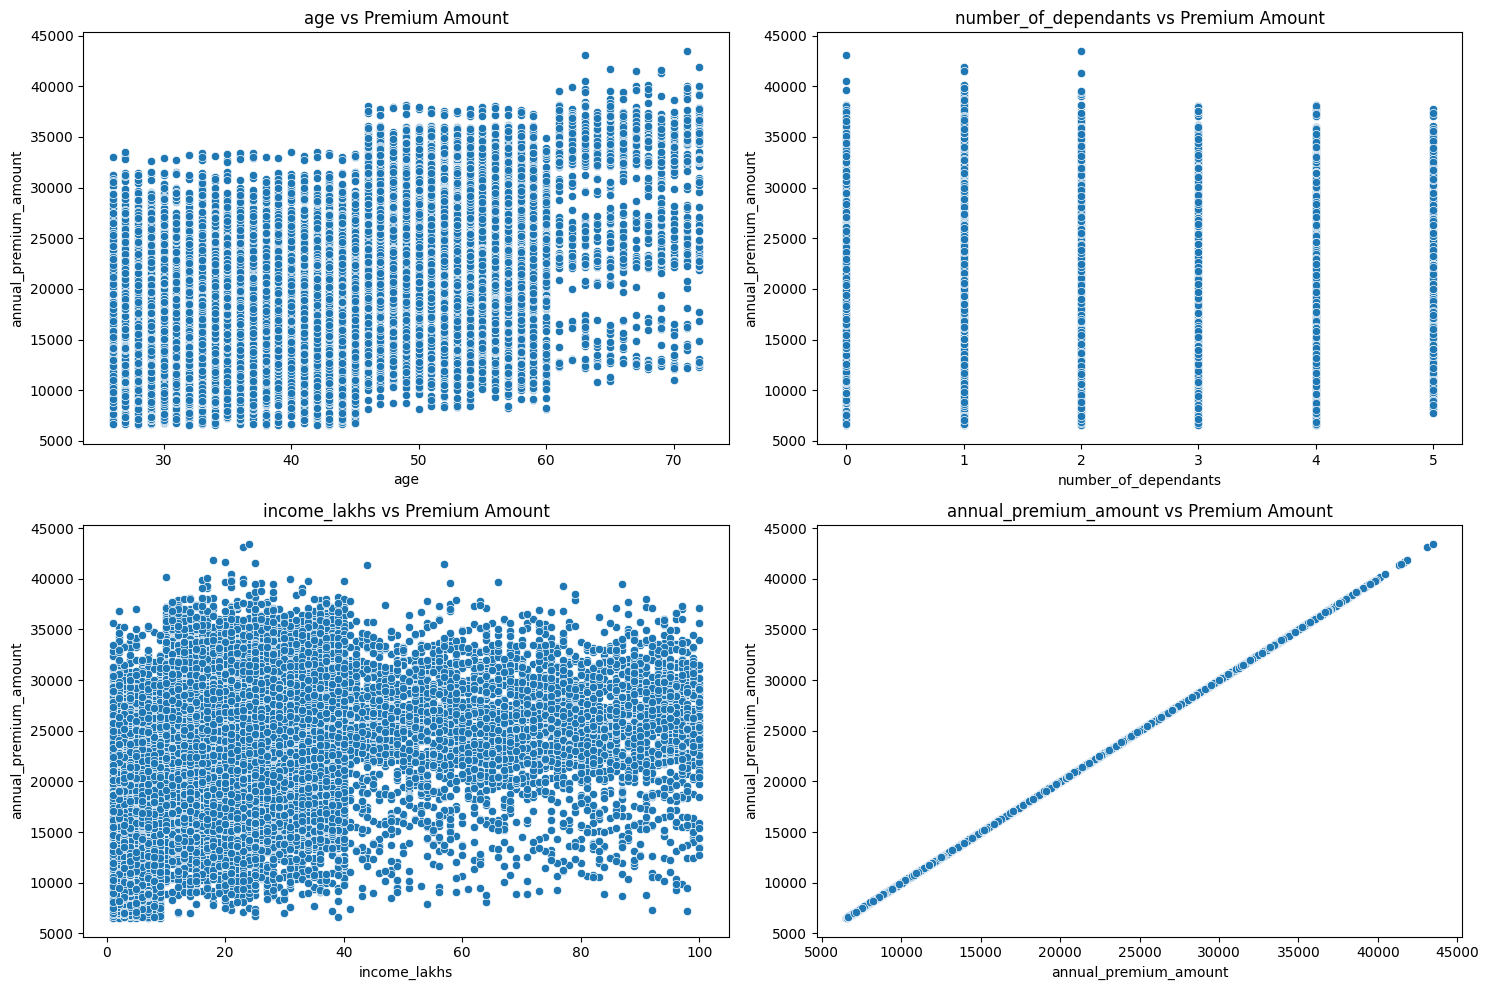

In [110]:
# two layouts for scatter plots
numeric_columns = df2.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for i, col in enumerate(numeric_columns):
    sns.scatterplot(x=df2[col], y=df2['annual_premium_amount'], ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'{col} vs Premium Amount')
plt.tight_layout()
plt.show()


In [111]:
categorical_columns = df2.select_dtypes(include='object').columns
for col in categorical_columns:
    print(f'Value counts for {col}:')
    print(df2[col].unique())

Value counts for gender:
['Male' 'Female']
Value counts for region:
['Northwest' 'Southeast' 'Northeast' 'Southwest']
Value counts for marital_status:
['Unmarried' 'Married']
Value counts for bmi_category:
['Normal' 'Obesity' 'Overweight' 'Underweight']
Value counts for smoking_status:
['No Smoking' 'Regular' 'Occasional' 'Does Not Smoke' 'Not Smoking'
 'Smoking=0']
Value counts for employment_status:
['Salaried' 'Self-Employed' 'Freelancer']
Value counts for income_level:
['<10L' '10L - 25L' '> 40L' '25L - 40L']
Value counts for medical_history:
['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
Value counts for insurance_plan:
['Bronze' 'Silver' 'Gold']


In [112]:
df2['smoking_status'].replace(
    {
        'Smoking=0':'No Smoking',
         'Does Not Smoke':'No Smoking',
         'Not Smoking':'No Smoking',
    },
    inplace=True
)
df2['smoking_status'].unique()

C:\Users\hapatil\AppData\Local\Temp\ipykernel_32352\2684999231.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['smoking_status'].replace(


array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

In [113]:
ptc_count =df2['gender'].value_counts(normalize=True)
ptc_count

gender
Male      0.549125
Female    0.450875
Name: proportion, dtype: float64

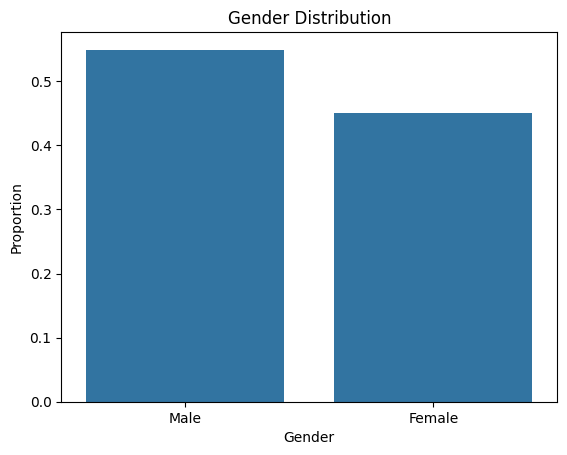

In [114]:
sns.barplot(x=ptc_count.index, y=ptc_count.values)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Proportion')    
plt.show()

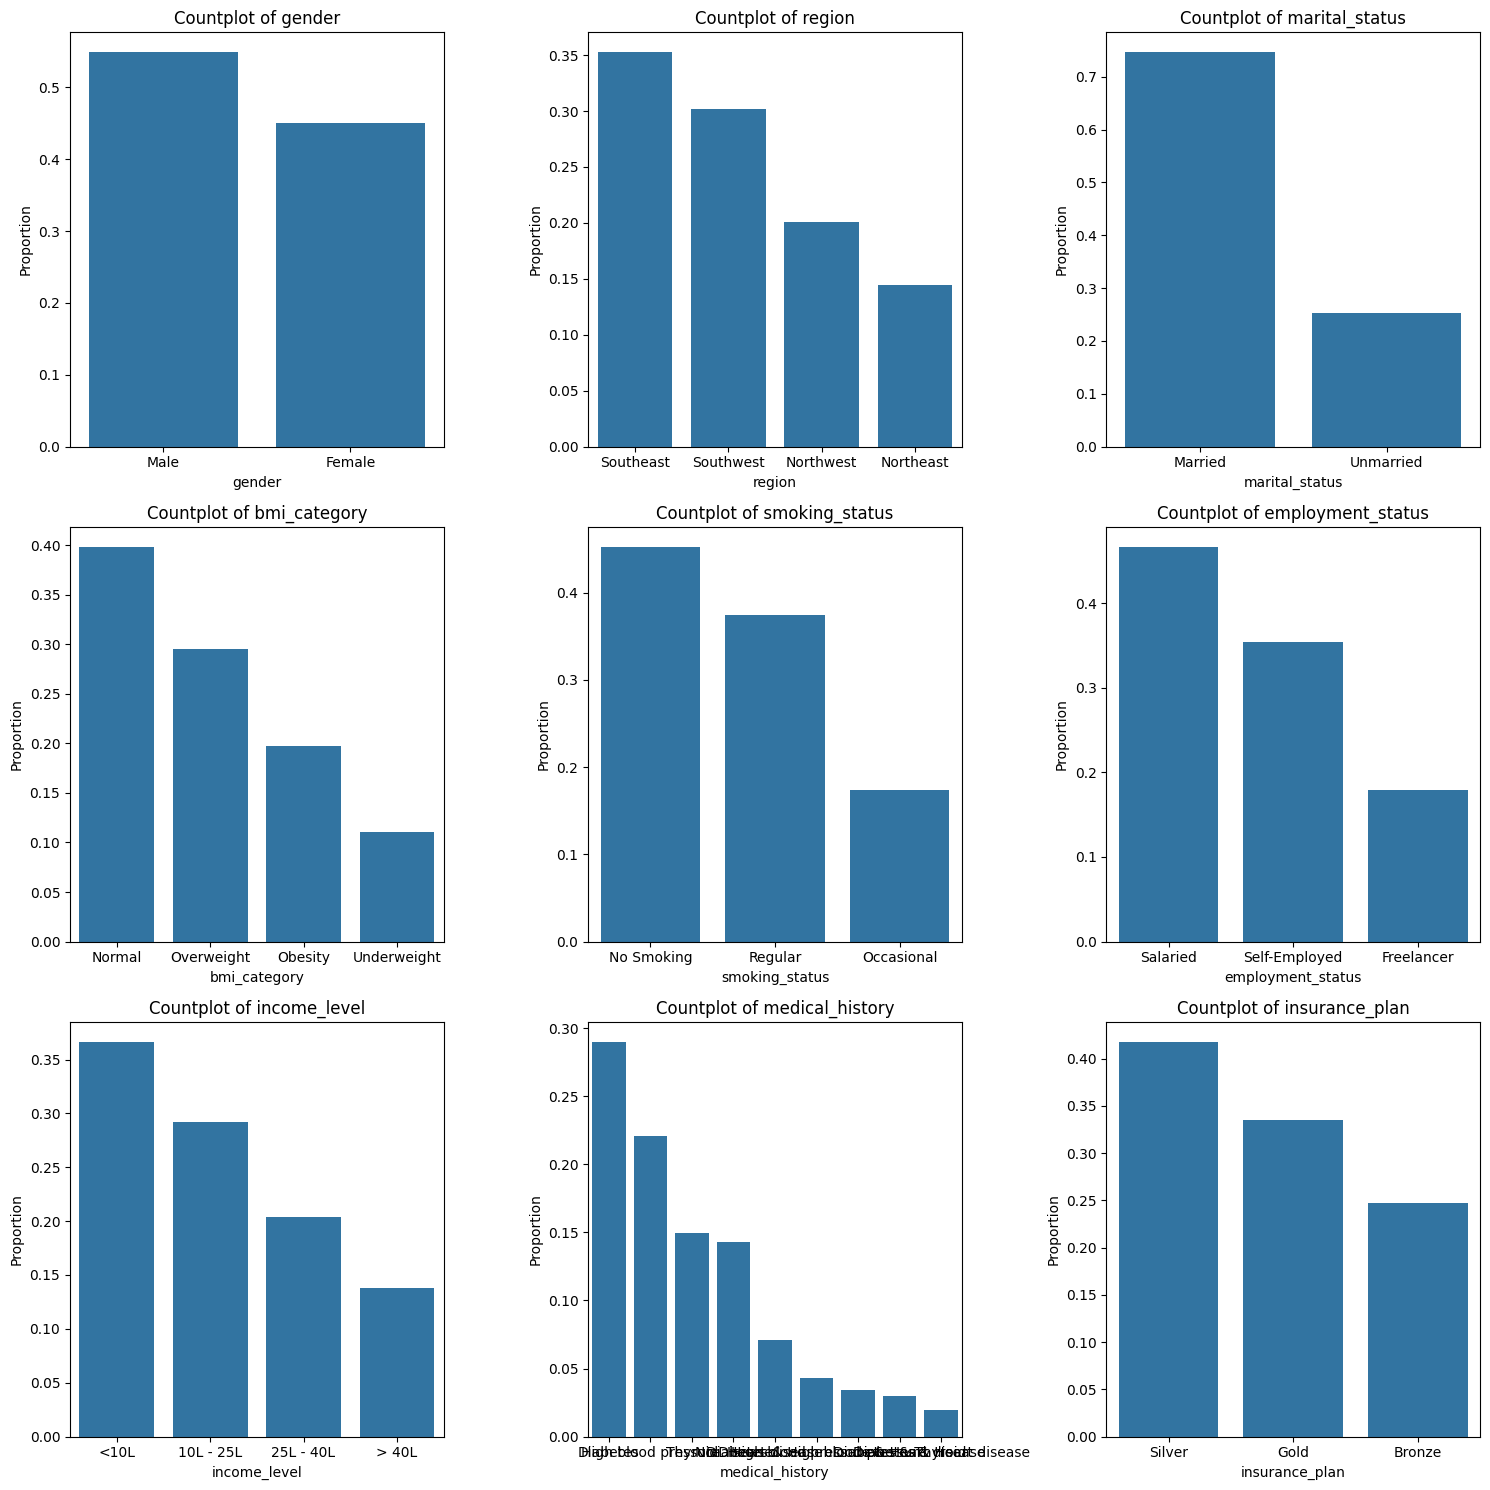

In [115]:
import math

n_plots = len(categorical_columns)
n_cols = 3
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(categorical_columns):
    counts = df2[col].value_counts(normalize=True)
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i])
    axes[i].set_title(f'Countplot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Proportion')

# Hide any unused subplot axes
for j in range(n_plots, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

insurance_plan  Bronze  Gold  Silver
income_range                        
<10L              6054   527    4341
10L-25L            742  3338    4106
25L-40L            339  2685    3188
>40L               233  3449     820


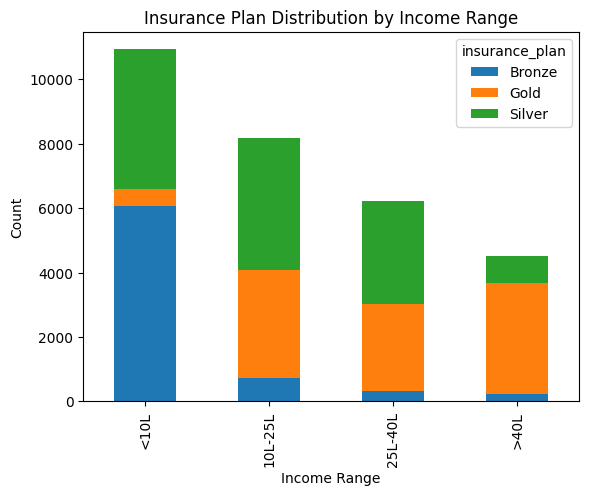

In [116]:
# Create income ranges in lakhs
income_bins = [float('-inf'), 10, 25, 40, float('inf')]
income_labels = ['<10L', '10L-25L', '25L-40L', '>40L']

df2['income_range'] = pd.cut(
    df2['income_lakhs'],
    bins=income_bins,
    labels=income_labels,
    right=False
 )

crosstab = pd.crosstab(df2['income_range'], df2['insurance_plan'])
print(crosstab)

crosstab.plot(kind='bar', stacked=True)
plt.title('Insurance Plan Distribution by Income Range')
plt.xlabel('Income Range')
plt.ylabel('Count')
plt.show()

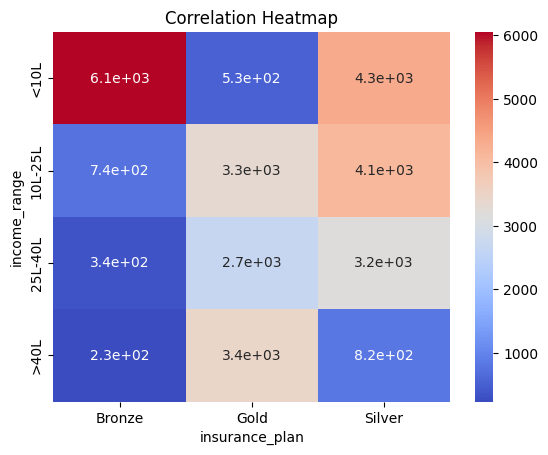

In [117]:
sns.heatmap(crosstab, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')    
plt.show()

In [118]:
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,income_range
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,<10L
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,<10L
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,10L-25L
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,>40L
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,10L-25L


In [119]:
df2.medical_history.unique()

array(['Diabetes', 'High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes & Heart disease'], dtype=object)

In [120]:
risk_scores = {
    "diabetes": 6, 
    "high blood pressure": 6, 
    "no disease": 0,
    "thyroid": 5, 
    "heart disease": 8,
    "none": 0       
}

In [121]:
df2[["disease1","disease2"]] = df2.medical_history.str.split(" & ", expand=True).apply(lambda x: x.str.lower())
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,income_range,disease1,disease2
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,<10L,diabetes,None
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,<10L,diabetes,None
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,10L-25L,high blood pressure,None
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,>40L,no disease,None
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,10L-25L,diabetes,None


In [122]:
df2['disease1'].fillna('none', inplace=True)
df2['disease2'].fillna('none', inplace=True)

df2['total_risk_score'] = 0

for disease_col in ['disease1', 'disease2']:
    df2['total_risk_score'] += df2[disease_col].map(risk_scores)

max_risk_score = df2['total_risk_score'].max()
min_risk_score = df2['total_risk_score'].min()
df2['normalized_risk_score'] = (df2['total_risk_score'] - min_risk_score) / (max_risk_score - min_risk_score)
df2.head(5)

C:\Users\hapatil\AppData\Local\Temp\ipykernel_32352\3450494256.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['disease1'].fillna('none', inplace=True)
C:\Users\hapatil\AppData\Local\Temp\ipykernel_32352\3450494256.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,income_range,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,<10L,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,<10L,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,10L-25L,high blood pressure,none,6,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,>40L,no disease,none,0,0.000000
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,10L-25L,diabetes,none,6,0.428571


In [123]:
df2.insurance_plan.unique()

array(['Bronze', 'Silver', 'Gold'], dtype=object)

In [124]:
df2['insurance_plan'] = df2['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})
df2.head()
df2['insurance_plan'].unique()

array([1, 2, 3])

In [125]:
df2['income_level'].unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L'], dtype=object)

In [126]:
df2['income_level'] = df2['income_level'].map({'<10L': 1, '10L - 25L': 2, '25L - 40L': 3, '> 40L': 4})
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,income_range,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,1,6,Diabetes,1,9053,<10L,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,1,6,Diabetes,1,16339,<10L,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,2,20,High blood pressure,2,18164,10L-25L,high blood pressure,none,6,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,4,77,No Disease,3,20303,>40L,no disease,none,0,0.000000
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,2,14,Diabetes,1,15610,10L-25L,diabetes,none,6,0.428571


In [127]:
nominal_cols = ['gender', 'region','marital_status','bmi_category','smoking_status', 'employment_status']
df3 = pd.get_dummies(df2, columns=nominal_cols, drop_first=True, dtype=int)

In [128]:
df3.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,income_range,disease1,disease2,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,<10L,diabetes,none,...,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,<10L,diabetes,none,...,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,High blood pressure,2,18164,10L-25L,high blood pressure,none,...,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,No Disease,3,20303,>40L,no disease,none,...,1,0,0,0,0,0,0,0,1,0
4,56,3,2,14,Diabetes,1,15610,10L-25L,diabetes,none,...,0,0,0,1,0,0,1,0,0,1


In [129]:
df4 = df3.drop(columns=['disease1', 'disease2', 'total_risk_score', 'medical_history', 'income_range'],axis=1)
df4.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,3,20303,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,56,3,2,14,1,15610,0.428571,1,0,0,0,0,1,0,0,1,0,0,1


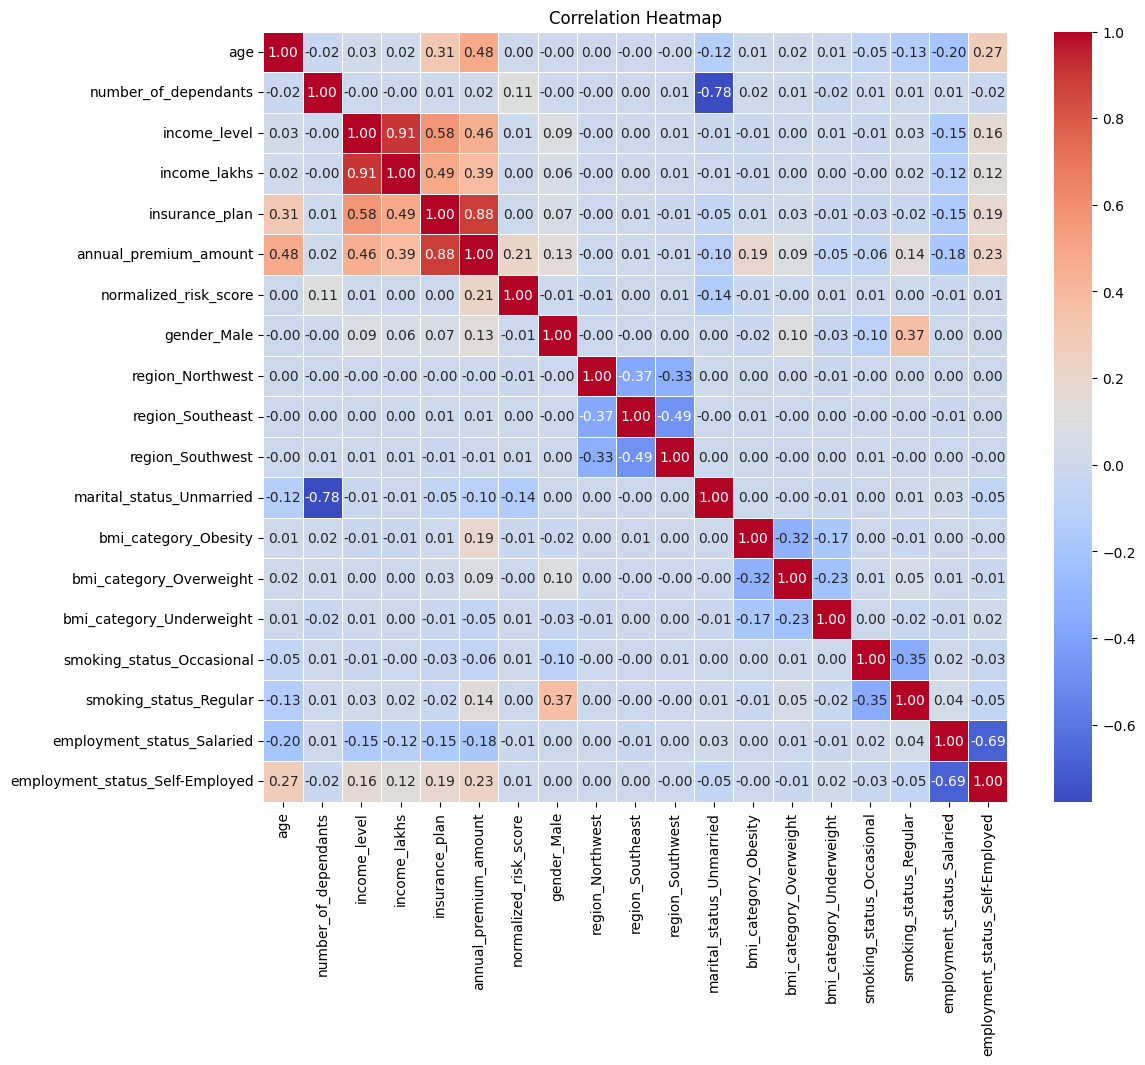

In [130]:
cm = df4.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [131]:
df4.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,3,20303,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,56,3,2,14,1,15610,0.428571,1,0,0,0,0,1,0,0,1,0,0,1


In [132]:
y = df4['annual_premium_amount']
X = df4.drop(columns=['annual_premium_amount'], axis='columns')

from sklearn.preprocessing import MinMaxScaler
columns_to_scale = ['age', 'number_of_dependants', 'income_level', 'income_lakhs', 'insurance_plan']
scaler = MinMaxScaler()
X[columns_to_scale] = scaler.fit_transform(X[columns_to_scale])
X.head()



,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.0,0.000000,0.050505,0.0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,0.065217,0.4,0.000000,0.050505,0.0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,0.500000,0.4,0.333333,0.191919,0.5,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,0.086957,0.6,1.000000,0.767677,1.0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,0.652174,0.6,0.333333,0.131313,0.0,0.428571,1,0,0,0,0,1,0,0,1,0,0,1


In [133]:
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000
mean,0.371628,0.477547,0.371225,0.224509,0.544112,0.426373,0.549125,0.200691,0.352693,0.301992,0.253336,0.196835,0.295051,0.110087,0.173228,0.374656,0.466132,0.354269
std,0.240053,0.284129,0.351111,0.226822,0.379009,0.240084,0.497589,0.400524,0.477816,0.459129,0.434929,0.397613,0.456073,0.313003,0.378450,0.484042,0.498860,0.478299
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.173913,0.200000,0.000000,0.060606,0.500000,0.357143,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.347826,0.600000,0.333333,0.161616,0.500000,0.428571,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.565217,0.600000,0.666667,0.313131,1.000000,0.428571,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [134]:
from  statsmodels.stats.outliers_influence import variance_inflation_factor
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data['Column'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

In [135]:
calculate_vif(X)

,Column,VIF
0,age,3.921783
1,number_of_dependants,6.278938
2,income_level,13.890522
3,income_lakhs,11.185596
4,insurance_plan,5.271297
5,normalized_risk_score,3.810619
6,gender_Male,2.599098
7,region_Northwest,2.123965
8,region_Southeast,2.980842
9,region_Southwest,2.710097


In [136]:
calculate_vif(X.drop(columns=['income_level'], axis='columns'))

,Column,VIF
0,age,3.863055
1,number_of_dependants,6.278147
2,income_lakhs,2.678102
3,insurance_plan,4.574625
4,normalized_risk_score,3.808345
5,gender_Male,2.591439
6,region_Northwest,2.123277
7,region_Southeast,2.979899
8,region_Southwest,2.708641
9,marital_status_Unmarried,2.345757


In [137]:
X_reduced = X.drop(columns=['income_level'], axis='columns')
X_reduced.head()

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.0,0.050505,0.0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,0.065217,0.4,0.050505,0.0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,0.500000,0.4,0.191919,0.5,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,0.086957,0.6,0.767677,1.0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,0.652174,0.6,0.131313,0.0,0.428571,1,0,0,0,0,1,0,0,1,0,0,1


### Model training

In [138]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.3, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)    
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (20875, 17)
X_test shape: (8947, 17)
y_train shape: (20875,)
y_test shape: (8947,)


In [139]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)
print("Test model score:", model_lr.score(X_test, y_test))
print("Train model score:", model_lr.score(X_train, y_train))

Mean Squared Error (MSE): 2183801.881857191
Root Mean Squared Error (RMSE): 1477.7692248308567
R-squared (R2): 0.9546117251336063
Test model score: 0.9546117251336063
Train model score: 0.9530815646744318


In [140]:
model_lr.coef_

array([ 7014.39496675, -1247.79337884,  -748.5047392 , 14840.07632438,
        6029.14742861,    42.76580366,   -76.16565671,   -25.08331687,
         -53.33779201,  -702.17193058,  3930.46262822,  1999.07429281,
         598.45525871,   855.18031748,  2816.79153464,   -73.4601338 ,
         248.75420828])

In [141]:
feature_importances = model_lr.coef_ 
coef_df = pd.DataFrame(feature_importances, index=X_reduced.columns, columns=['Coefficients'])
coef_df.sort_values(by='Coefficients',  ascending=True, inplace=True)
print(coef_df)

                                 Coefficients
number_of_dependants             -1247.793379
income_lakhs                      -748.504739
marital_status_Unmarried          -702.171931
region_Northwest                   -76.165657
employment_status_Salaried         -73.460134
region_Southwest                   -53.337792
region_Southeast                   -25.083317
gender_Male                         42.765804
employment_status_Self-Employed    248.754208
bmi_category_Underweight           598.455259
smoking_status_Occasional          855.180317
bmi_category_Overweight           1999.074293
smoking_status_Regular            2816.791535
bmi_category_Obesity              3930.462628
normalized_risk_score             6029.147429
age                               7014.394967
insurance_plan                   14840.076324


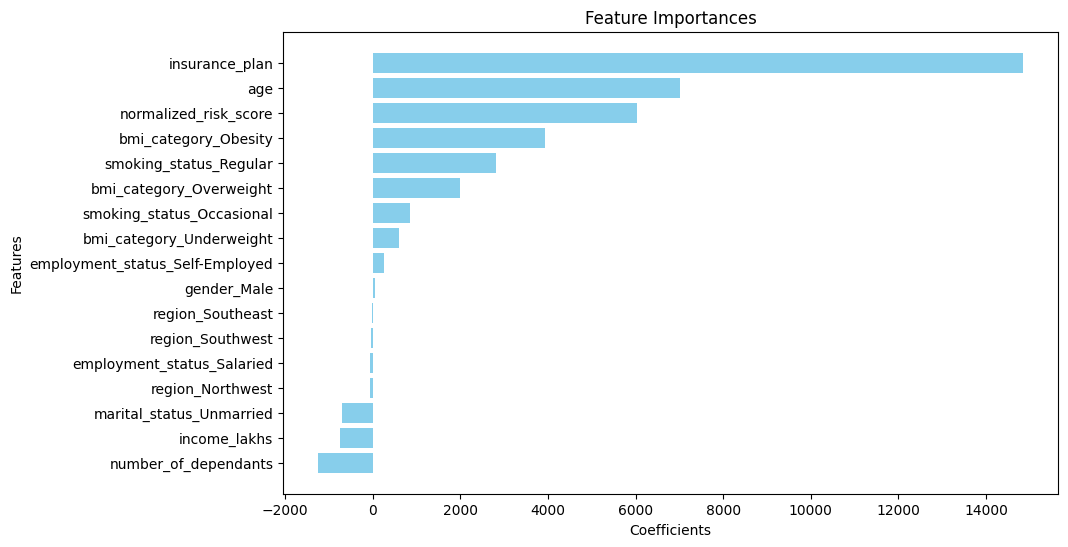

In [142]:

plt.figure(figsize=(10, 6))
plt.barh(coef_df.index, coef_df['Coefficients'], color='skyblue')
plt.xlabel("Coefficients")
plt.ylabel("Features")
plt.title("Feature Importances")
plt.show()

In [143]:
model_rg = Ridge(alpha=1.0)
model_rg.fit(X_train, y_train)

y_pred_rg = model_rg.predict(X_test)
mse_rg = mean_squared_error(y_test, y_pred_rg)
rmse_rg = np.sqrt(mse_rg)
r2_rg = r2_score(y_test, y_pred_rg)

print("Ridge Regression Mean Squared Error (MSE):", mse_rg)
print("Ridge Regression Root Mean Squared Error (RMSE):", rmse_rg)
print("Ridge Regression R-squared (R2):", r2_rg)
print("Ridge Regression Test model score:", model_rg.score(X_test, y_test))
print("Ridge Regression Train model score:", model_rg.score(X_train, y_train))

Ridge Regression Mean Squared Error (MSE): 2183773.4154461706
Ridge Regression Root Mean Squared Error (RMSE): 1477.759593251274
Ridge Regression R-squared (R2): 0.954612316781273
Ridge Regression Test model score: 0.954612316781273
Ridge Regression Train model score: 0.9530813964457598


In [144]:
from xgboost import XGBRegressor
model_xg = XGBRegressor(random_state=42)
model_xg.fit(X_train, y_train)

y_pred_xg = model_xg.predict(X_test)
mse_xg = mean_squared_error(y_test, y_pred_xg)
rmse_xg = np.sqrt(mse_xg)
r2_xg = r2_score(y_test, y_pred_xg)

print("XGBoost Regression Mean Squared Error (MSE):", mse_xg)
print("XGBoost Regression Root Mean Squared Error (RMSE):", rmse_xg)
print("XGBoost Regression R-squared (R2):", r2_xg)
print("XGBoost Regression Test model score:", model_xg.score(X_test, y_test))
print("XGBoost Regression Train model score:", model_xg.score(X_train, y_train))

XGBoost Regression Mean Squared Error (MSE): 95726.203125
XGBoost Regression Root Mean Squared Error (RMSE): 309.3965144034431
XGBoost Regression R-squared (R2): 0.9980103969573975
XGBoost Regression Test model score: 0.9980103969573975
XGBoost Regression Train model score: 0.9986148476600647


In [145]:
# Compatibility patch for sklearn 1.6 + older xgboost wrappers
from sklearn.base import RegressorMixin
from sklearn.utils._tags import Tags, TargetTags, RegressorTags

def _patched_sklearn_tags(self):
    return Tags(
        estimator_type='regressor',
        target_tags=TargetTags(required=True),
        regressor_tags=RegressorTags(),
    )

RegressorMixin.__sklearn_tags__ = _patched_sklearn_tags

model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
}
random_search = RandomizedSearchCV(
    estimator=model_xgb,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=1
)
random_search.fit(X_train, y_train)
print(random_search.best_params_)
print(random_search.best_score_)

{'n_estimators': 50, 'max_depth': 7, 'learning_rate': 0.1}
0.9975584506988525


In [146]:
best_model = random_search.best_estimator_

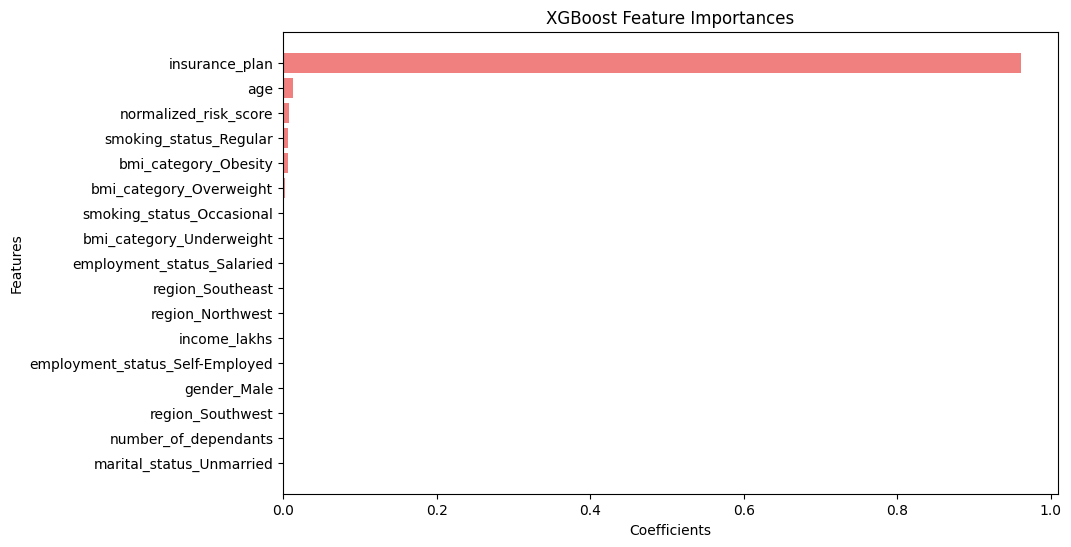

In [147]:
frature_importances = best_model.feature_importances_
coef_df_xgb = pd.DataFrame(frature_importances, index=X_reduced.columns, columns=['Coefficients'])
coef_df_xgb.sort_values(by='Coefficients', ascending=True, inplace=True)

plt.figure(figsize=(10, 6))
plt.barh(coef_df_xgb.index, coef_df_xgb['Coefficients'], color='lightcoral')
plt.xlabel("Coefficients")
plt.ylabel("Features")
plt.title("XGBoost Feature Importances")
plt.show()

### Error Analysis

In [148]:
y_pred_xgb = best_model.predict(X_test)

residuals = y_test - y_pred_xgb
residuals_pct = residuals*100 / y_test

residuals_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_xgb,
    'Residuals': residuals,
    'Residuals (%)': residuals_pct
})
residuals_df.head(10)

,Actual,Predicted,Residuals,Residuals (%)
5495,30838,31032.929688,-194.929688,-0.632109
582,26306,26181.671875,124.328125,0.472623
281,17983,17468.234375,514.765625,2.862513
15443,19345,18889.121094,455.878906,2.356572
24281,33317,33350.218750,-33.218750,-0.099705
13879,17888,17468.234375,419.765625,2.346633
23869,13338,13454.430664,-116.430664,-0.872924
9985,22635,22422.642578,212.357422,0.938182
1989,18057,18504.326172,-447.326172,-2.477301
29096,9614,9518.857422,95.142578,0.989625


<Axes: xlabel='Residuals (%)', ylabel='Count'>

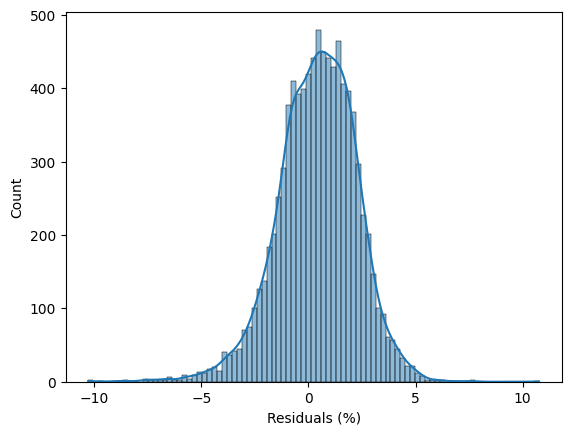

In [149]:
sns.histplot(residuals_df['Residuals (%)'], kde=True)

In [150]:
extreme_error_threshold = 10
extreme_results_df = residuals_df[np.abs(residuals_df['Residuals (%)']) > extreme_error_threshold]
extreme_results_df.shape

(3, 4)

In [151]:
extreme_error_percentage = extreme_results_df.shape[0]*100 / residuals_df.shape[0]
extreme_error_percentage

0.03353079244439477

In [152]:
residuals_df[np.abs(residuals_df['Residuals (%)']) > 50].sort_values(by='Residuals (%)', ascending=False).head(10)

,Actual,Predicted,Residuals,Residuals (%)


In [153]:
X_test.index

Index([ 5495,   582,   281, 15443, 24281, 13879, 23869,  9985,  1989, 29096,
       ...
        9378, 21318, 11748, 12471, 27270, 12305,  2117, 23521, 29683, 11077],
      dtype='int64', length=8947)

In [154]:
extreme_results_df.index

Index([6137, 9664, 8270], dtype='int64')

In [155]:
extreme_errors_df = X_test.loc[extreme_results_df.index]
extreme_errors_df.head()

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
6137,0.369565,0.2,0.040404,0.0,0.000000,1,0,0,1,1,0,0,0,0,0,0,0
9664,0.891304,0.2,0.040404,0.5,0.571429,0,0,1,0,0,1,0,0,0,1,1,0
8270,0.282609,0.0,0.000000,0.0,0.000000,0,0,1,0,1,0,0,0,0,0,1,0


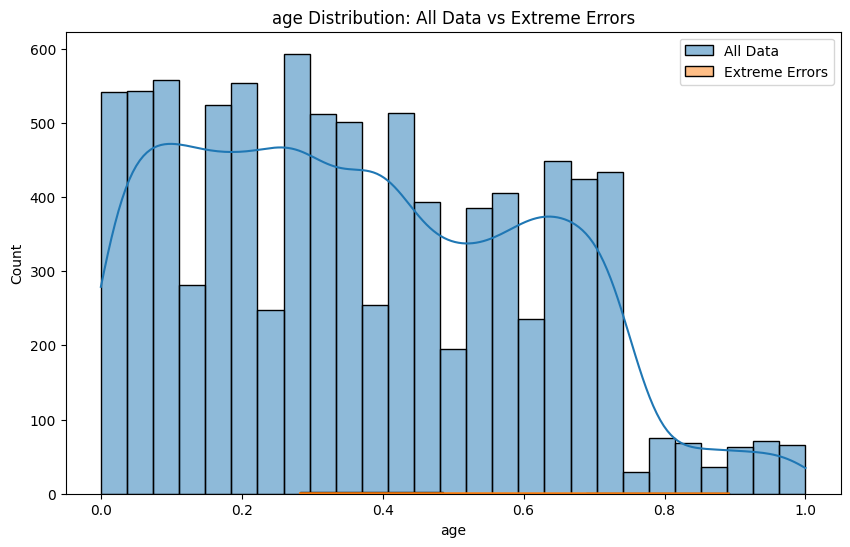

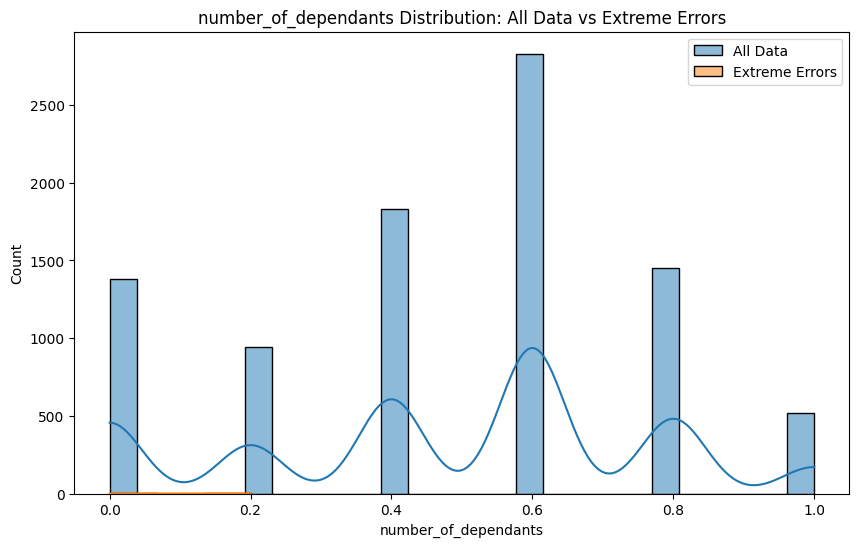

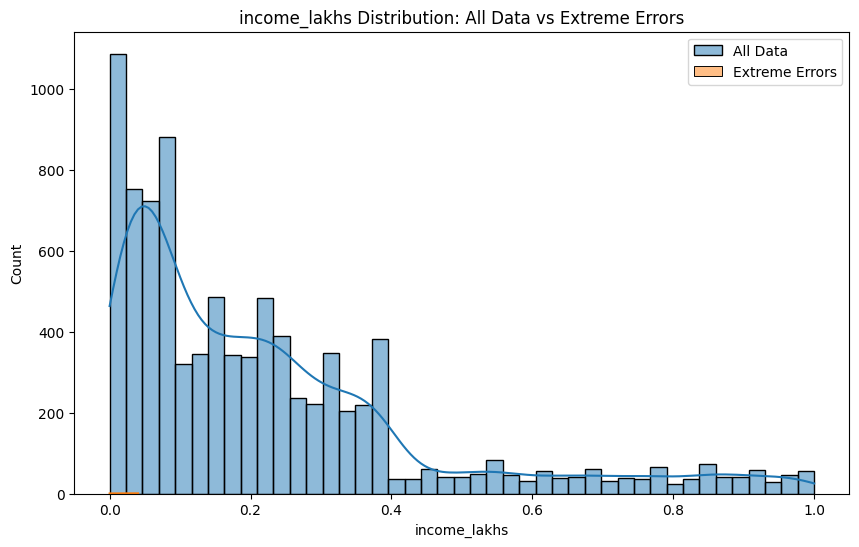

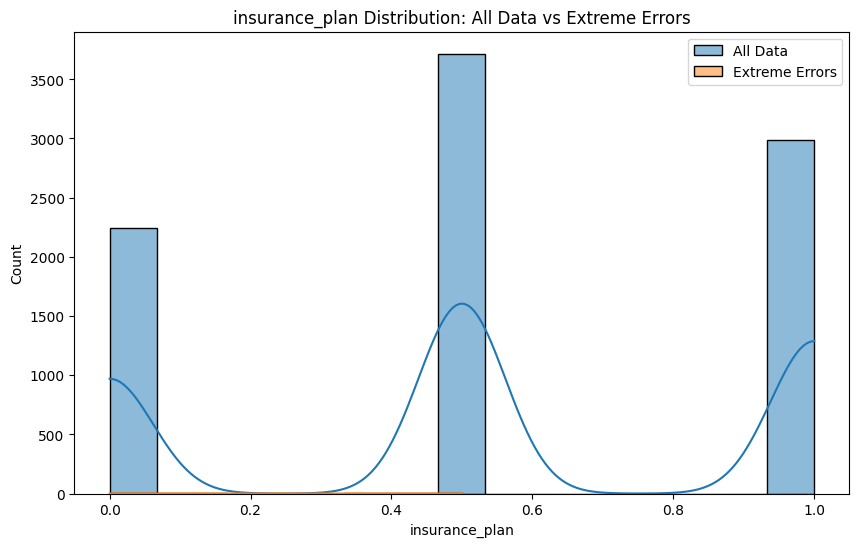

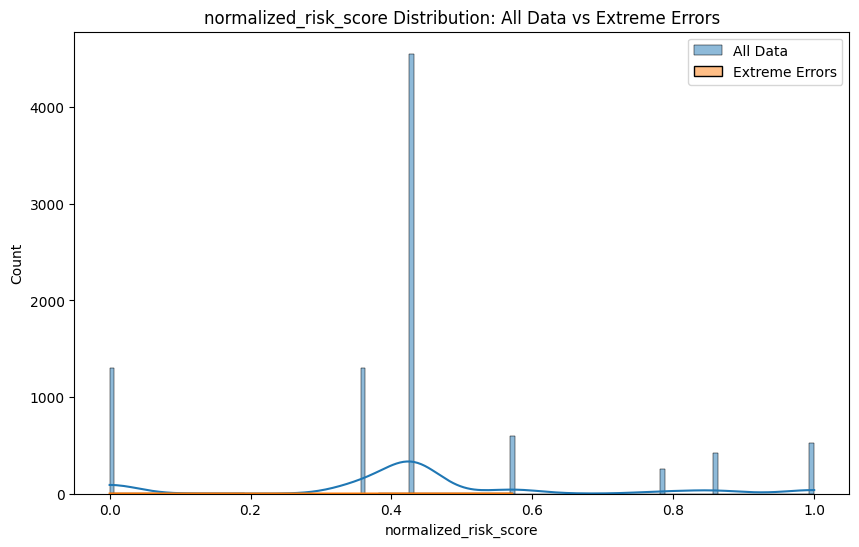

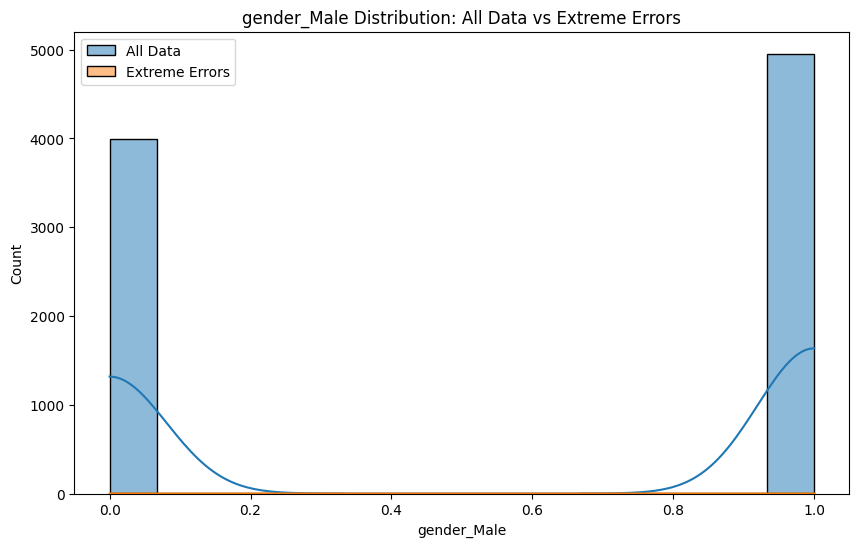

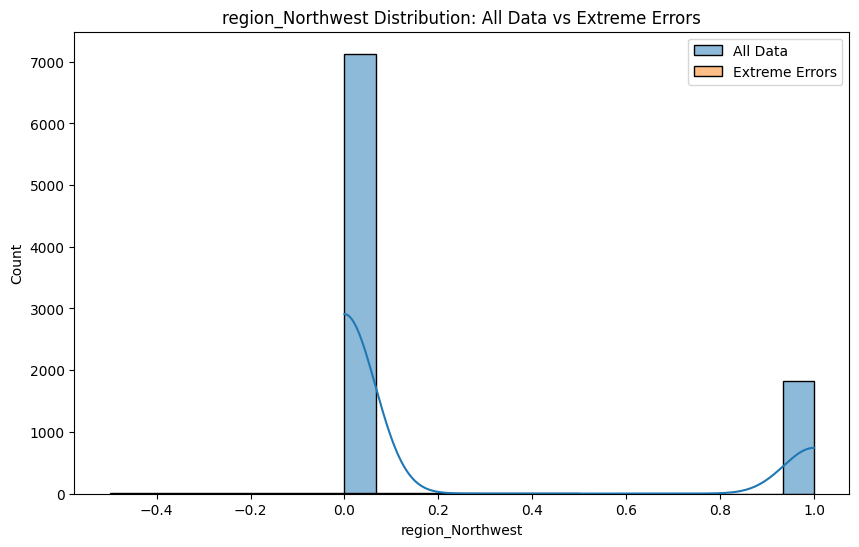

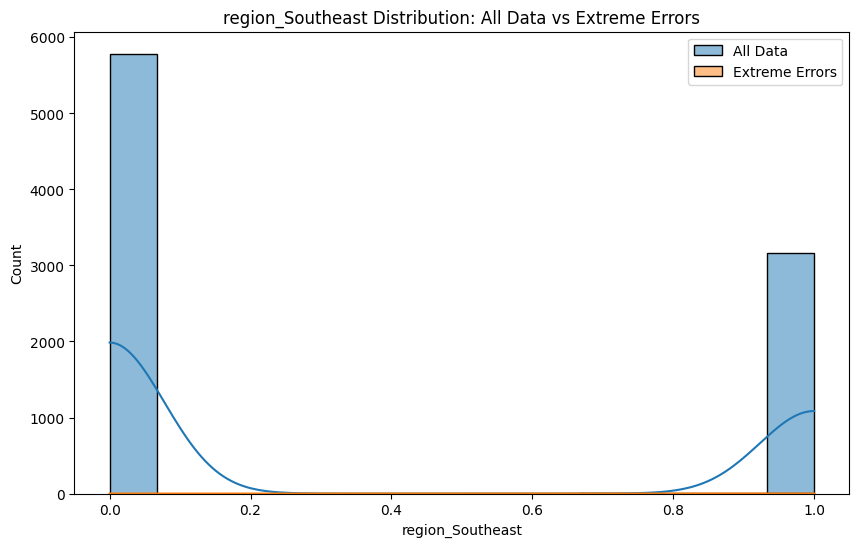

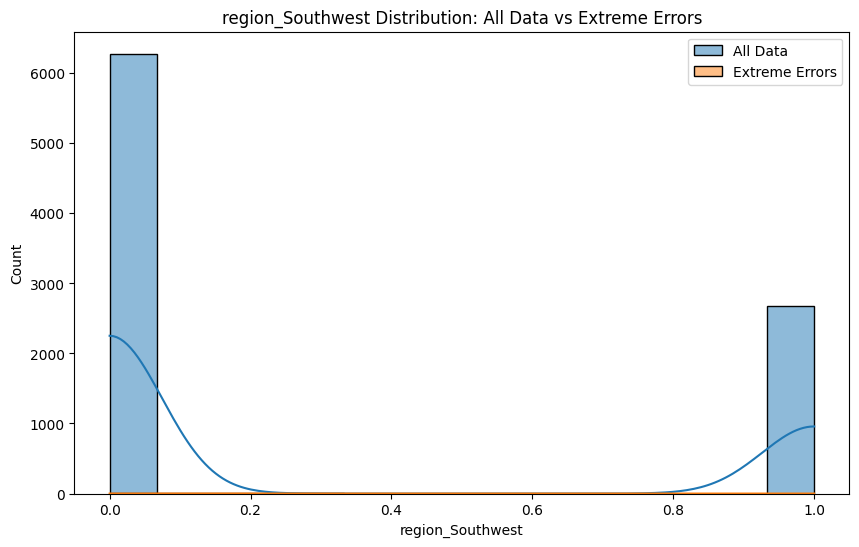

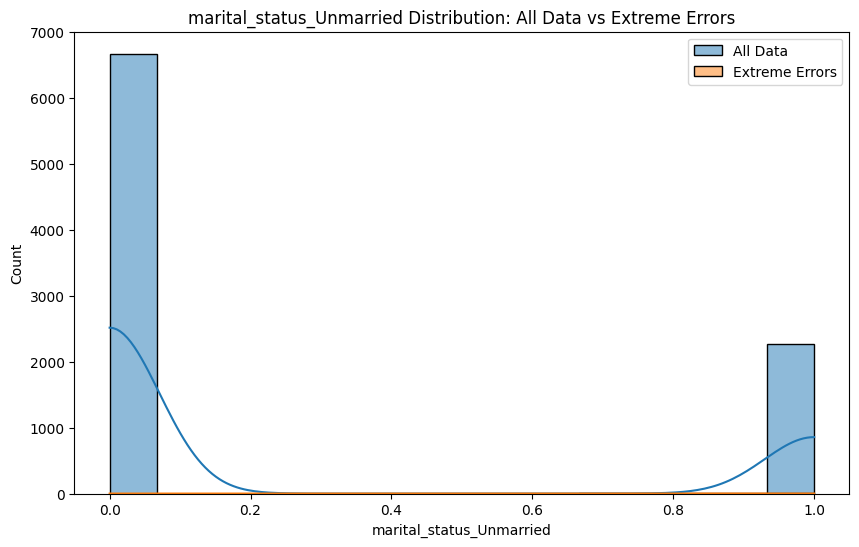

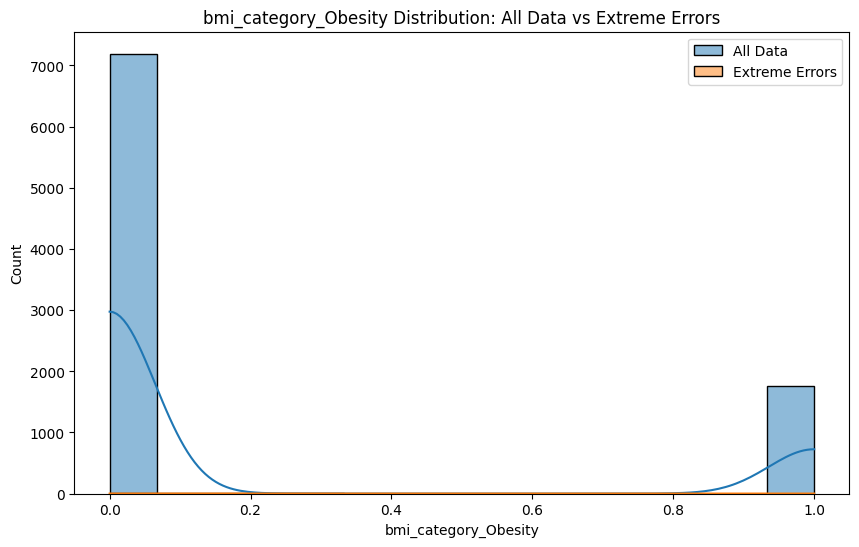

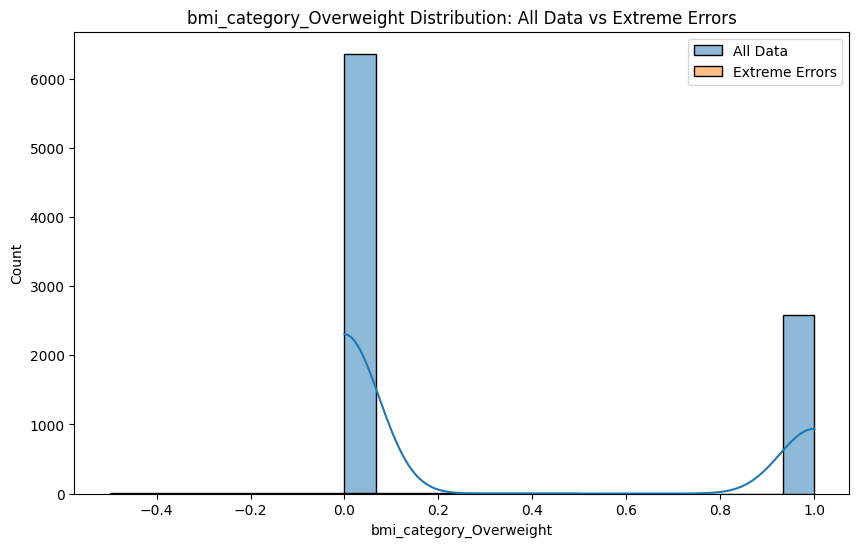

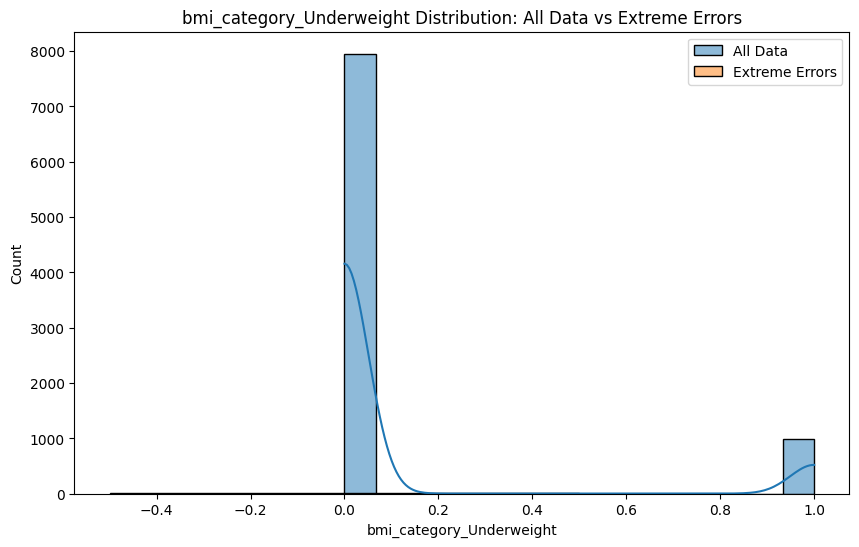

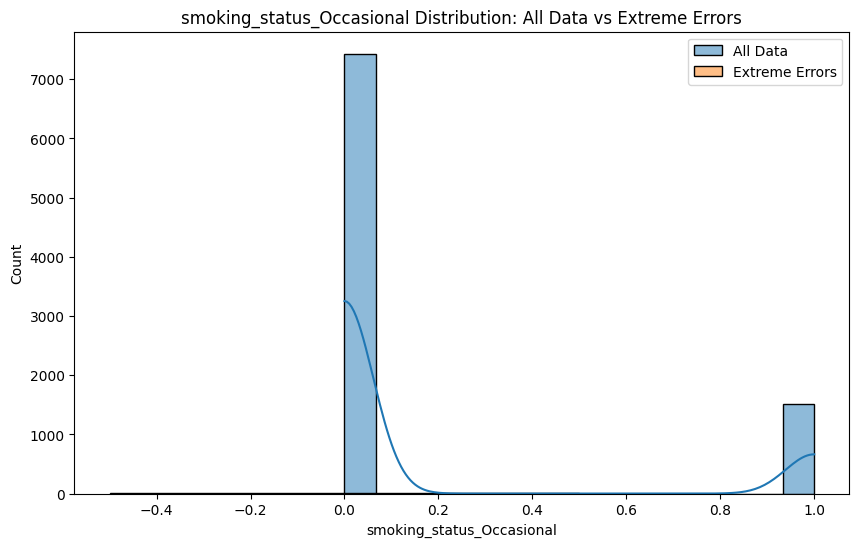

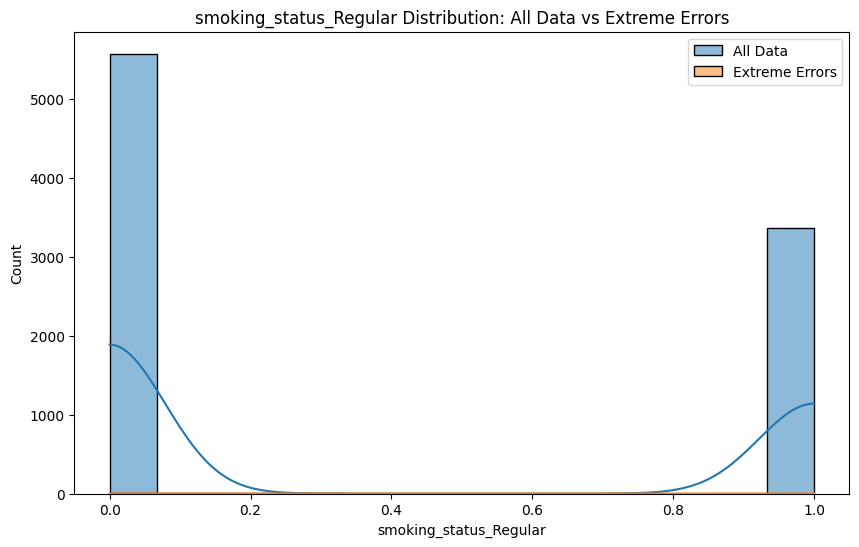

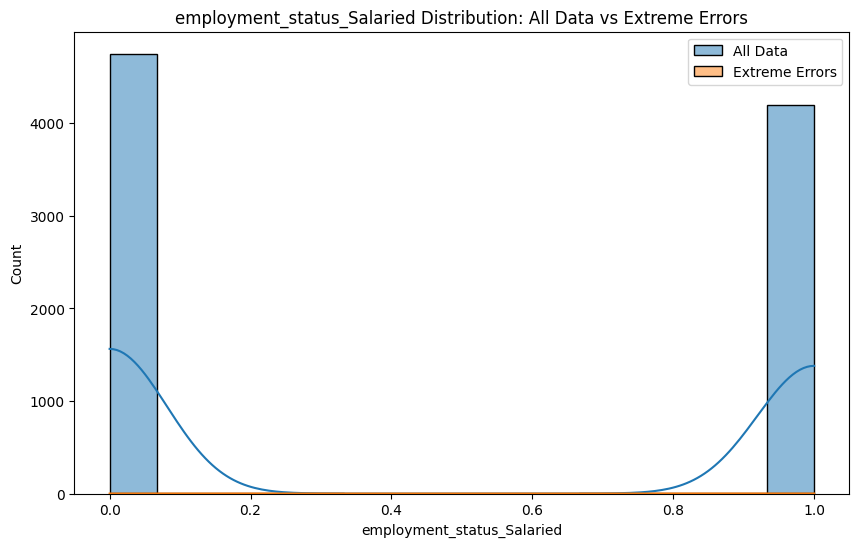

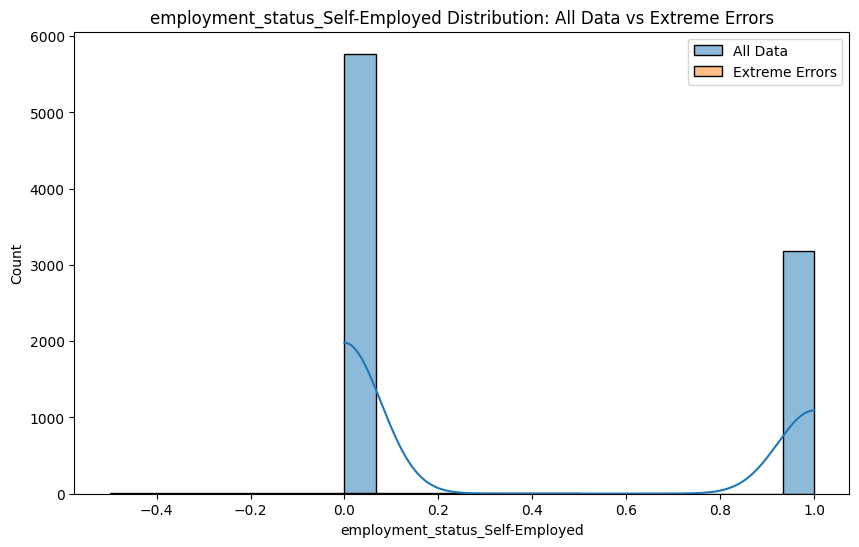

In [156]:
for feature in X_test.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(X_test[feature], label='All Data', kde=True)
    sns.histplot(extreme_errors_df[feature], label='Extreme Errors', kde=True)
    plt.legend()
    plt.title(f'{feature} Distribution: All Data vs Extreme Errors')
    plt.show()

In [157]:
cols_to_scale = ['age', 'number_of_dependants', 'income_level', 'income_lakhs', 'insurance_plan']

In [158]:
extreme_errors_df['income_level'] = -1

<Axes: xlabel='age', ylabel='Count'>

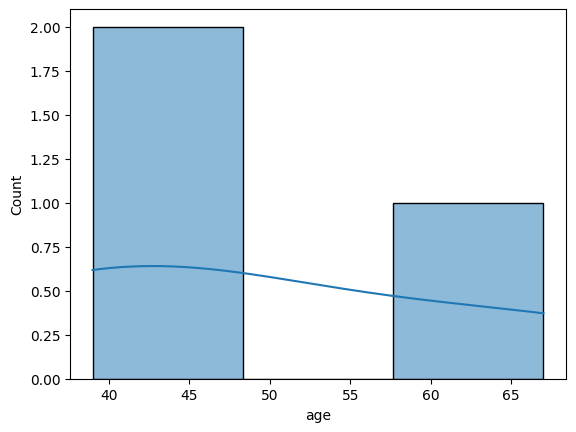

In [159]:
df_reversed = pd.DataFrame() 
df_reversed[cols_to_scale] = scaler.inverse_transform(extreme_errors_df[cols_to_scale])

df_reversed

sns.histplot(df_reversed['age'], kde=True)

In [160]:
df_reversed['age'].quantile(0.97)

np.float64(65.56)